In [3]:
import os
from pathlib import Path

import numpy as np
import torch as tc
import torchvision.transforms.v2 as tvs
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader
from tqdm import tqdm

from convnet import ConvNet
# from scatnet import ScatNet

RNG = tc.Generator().manual_seed(0)

# FIXME: remove transforms from validation and testing subsets
transforms = tvs.Compose([
    tvs.Grayscale(),
    tvs.ToImage(),
    # tvs.CenterCrop(128),
    tvs.Resize((128, 128)),
    # bit of data augmentation
    tvs.RandomHorizontalFlip(),
    tvs.GaussianNoise(),
    tvs.ConvertImageDtype(tc.float32),
])

ROOT = Path(os.environ["CHEST_XRAY"])

dataset = tc.utils.data.ConcatDataset([
    ImageFolder(Path(ROOT, "train"), transform=transforms),
    ImageFolder(Path(ROOT, "test"), transform=transforms),
])

BATCH_SIZE: int = 200
WORKERS: int = 2

train_dataset, test_dataset = tc.utils.data.random_split(dataset, [0.8, 0.2], generator=RNG)

device = tc.device("cuda")

SHAPE = (1, 128, 128)
model = ConvNet(shape=SHAPE).to(device)
# model.compile()

In [4]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import SubsetRandomSampler

EPOCHS: int = 20

criterion = tc.nn.CrossEntropyLoss().to(device)
optimizer = tc.optim.Adam(model.parameters())

acc_train = []; f1_train = []; loss_train = []
acc_valid = []; f1_valid = []; loss_valid = []

# cross validation
folds = StratifiedKFold(n_splits=5)
# dummy shape to generate the splits
X = np.zeros(len(train_dataset))
y = np.concat([x.targets for x in dataset.datasets])[train_dataset.indices]
for fold_index, (train_index, valid_index) in enumerate(folds.split(X, y)):
    train_loader = DataLoader(
        train_dataset,
        sampler=SubsetRandomSampler(train_index, generator=RNG),
        batch_size=BATCH_SIZE,
        num_workers=WORKERS,
        pin_memory=True,
    )
    valid_loader = DataLoader(
        train_dataset,
        sampler=SubsetRandomSampler(valid_index, generator=RNG),
        batch_size=BATCH_SIZE,
        num_workers=WORKERS,
        pin_memory=True,
    )

    # for epoch in tqdm(range(EPOCHS), "Training"):
    for epoch in range(EPOCHS):
        print(f"Fold: {fold_index} Epoch: {epoch}")

        running_loss = []
        running_acc = []
        running_f1 = []
        model.train()
        for images, labels in tqdm(train_loader, "Train on batches"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Compute accuracy, and F1-score
            predicted = tc.argmax(outputs, dim=-1)
            running_loss.append(loss.item())
            running_acc.append(accuracy_score(labels.cpu(), predicted.cpu()))
            running_f1.append(f1_score(labels.cpu(), predicted.cpu(), average="weighted"))
            # print("Batch accuracy score", accuracy_score(labels.cpu(), predicted.cpu()))

        loss_train.append(np.mean(running_loss))
        acc_train.append(np.mean(running_acc))
        f1_train.append(np.mean(running_f1))

        print(
            f"  Train - Loss: {loss_train[epoch]:.4f}, Acc: {acc_train[epoch]:.4f}, F1: {f1_train[epoch]:.4f}"
        )

        # Validation phase
        model.eval()
        running_loss = []
        running_acc = []
        running_f1 = []
        with tc.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                _, predicted = tc.max(outputs, 1)
                running_loss.append(loss.item())
                running_acc.append(accuracy_score(labels.cpu(), predicted.cpu()))
                running_f1.append(
                    f1_score(labels.cpu(), predicted.cpu(), average="weighted")
                )

            loss_valid.append(np.mean(running_loss))
            acc_valid.append(np.mean(running_acc))
            f1_valid.append(np.mean(running_f1))

            print(
                f"  Valid - Loss: {loss_valid[epoch]:.4f}, Acc: {acc_valid[epoch]:.4f}, F1: {f1_valid[epoch]:.4f}"
            )

Fold: 0 Epoch: 0


Train on batches: 100%|██████████| 19/19 [00:19<00:00,  1.01s/it]


  Train - Loss: 1.7310, Acc: 0.6181, F1: 0.5250
  Valid - Loss: 0.7506, Acc: 0.4318, F1: 0.3969
Fold: 0 Epoch: 1


Train on batches: 100%|██████████| 19/19 [00:19<00:00,  1.00s/it]


  Train - Loss: 0.5021, Acc: 0.7822, F1: 0.7538
  Valid - Loss: 0.3785, Acc: 0.8032, F1: 0.7780
Fold: 0 Epoch: 2


...

  Train - Loss: 0.1817, Acc: 0.9328, F1: 0.9321
  Valid - Loss: 0.2668, Acc: 0.8862, F1: 0.8818
Fold: 4 Epoch: 18


Train on batches: 100%|██████████| 19/19 [00:27<00:00,  1.43s/it]


  Train - Loss: 0.1836, Acc: 0.9357, F1: 0.9356
  Valid - Loss: 0.4911, Acc: 0.7774, F1: 0.7162
Fold: 4 Epoch: 19


Train on batches: 100%|██████████| 19/19 [00:27<00:00,  1.43s/it]


  Train - Loss: 0.1829, Acc: 0.9394, F1: 0.9388
  Valid - Loss: 0.5297, Acc: 0.7454, F1: 0.6533


In [5]:
# test the model

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=WORKERS,
    pin_memory=True,
)

def test_model(model: tc.nn.Module, images_loader: DataLoader):
    model.eval()
    all_preds = []
    all_labels = []
    with tc.no_grad():
        for images, labels in images_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = tc.argmax(outputs, dim=-1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f'Test Accuracy: {accuracy:.4f}, Test F1-score: {f1:.4f}')

test_model(model, test_loader)

Test Accuracy: 0.9539, Test F1-score: 0.9535


TypeError: Invalid shape (37, 102, 128) for image data

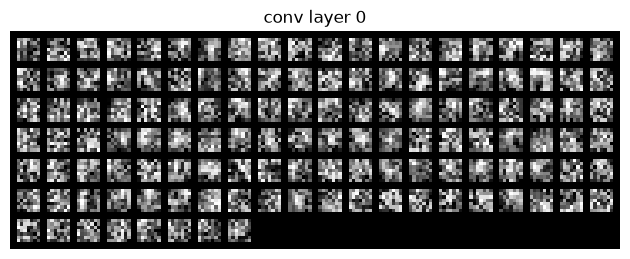

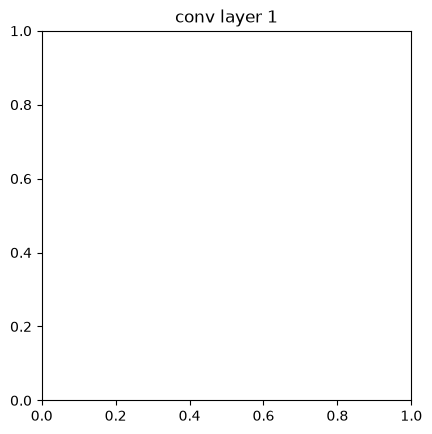

In [7]:
# visualize filters
import matplotlib.pyplot as plt
import torchvision

for i, layer in enumerate([model.conv0.weight, model.conv1.weight]):
    fig, ax = plt.subplots()
    ax.set_title(f"conv layer {i}")
    image = torchvision.utils.make_grid(layer.cpu(), nrow=20, normalize=True, scale_each=True)
    # bring channel axis to the last place
    ax.imshow(image.numpy().transpose((1, 2, 0)))
    ax.axis("off")
    fig.tight_layout()

In [ ]:
# export the trained model

save_folder = Path("./weights")
save_folder.mkdir(exist_ok=True)
tc.save(model.state_dict(), Path(save_folder, f"{model.name}.pt"))